# DATA 266 Lab 1 — Task 2: Yelp Polarity Sentiment Classification

**Student:** Yuyao Ding

## Objective

The goal of this task is to build and evaluate sentiment classification models on the Yelp Polarity dataset.

All models are trained from scratch without pretrained embeddings or pretrained language models.

The task includes:

1. Data exploration and preprocessing
2. Training one baseline model and two experimental models
3. Comprehensive model evaluation
4. Error analysis
5. Comparison of model performance and limitations

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!unzip -q "/content/drive/MyDrive/DATA266_Pair41_Lab1/task2_sentiment/data/yelp_polarity.zip" -d "/content/data/"

replace /content/data/train-00000-of-00001.parquet? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/__MACOSX/._train-00000-of-00001.parquet? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [3]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/content/data")

train_path = DATA_DIR / "train-00000-of-00001.parquet"
test_path = DATA_DIR / "test-00000-of-00001.parquet"

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Train shape: (560000, 2)
Test shape: (38000, 2)


,text,label
0,"Unfortunately, the frustration of being Dr. Go...",0
1,Been going to Dr. Goldberg for over 10 years. ...,1
2,I don't know what Dr. Goldberg was like before...,0
3,I'm writing this review to give you a heads up...,0
4,All the food is great here. But the best thing...,1


## 2.1 Data Preprocessing

This section prepares the Yelp Polarity dataset for sentiment classification.

The preprocessing pipeline includes:

- analysis of review length and class distribution,
- detection and handling of missing or malformed entries,
- text normalization,
- stopword removal while preserving sentiment-relevant negation words,
- tokenization,
- construction of a vocabulary from the training data only, and
- preparation for trainable word embeddings learned from scratch.

No pretrained embeddings or pretrained language models are used.

In [4]:
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from tqdm.auto import tqdm

import torch
import torch.nn as nn

SID4 = 640
SEED = SID4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

tqdm.pandas()

### 2.1.1 Dataset Inspection and Data Quality

The Yelp Polarity dataset contains two columns:

- `text`: the Yelp review text
- `label`: the sentiment class

Before performing text preprocessing, I inspect the dataset for missing values,
invalid labels, empty reviews, non-string text entries, and duplicate examples.

In [5]:
print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nTraining data types:")
print(train_df.dtypes)

print("\nFirst five training examples:")
display(train_df.head())

Training set shape: (560000, 2)
Test set shape: (38000, 2)

Columns:
['text', 'label']

Training data types:
text     object
label     int64
dtype: object

First five training examples:


,text,label
0,"Unfortunately, the frustration of being Dr. Go...",0
1,Been going to Dr. Goldberg for over 10 years. ...,1
2,I don't know what Dr. Goldberg was like before...,0
3,I'm writing this review to give you a heads up...,0
4,All the food is great here. But the best thing...,1


In [6]:
def inspect_data_quality(df, name):
    print(f"===== {name} =====")

    print("\nMissing values:")
    print(df.isnull().sum())

    non_string_text = (
        ~df["text"].apply(lambda x: isinstance(x, str))
    ).sum()

    print("\nNon-string text entries:", non_string_text)

    empty_text = (
        df["text"]
        .dropna()
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print("Empty or whitespace-only reviews:", empty_text)

    print("Unique labels:", sorted(df["label"].dropna().unique()))

    invalid_labels = (
        ~df["label"].isin([0, 1])
    ).sum()

    print("Invalid labels:", invalid_labels)

    duplicate_rows = df.duplicated(
        subset=["text", "label"]
    ).sum()

    print("Exact duplicate rows:", duplicate_rows)


inspect_data_quality(train_df, "Training Set")
print()
inspect_data_quality(test_df, "Test Set")

===== Training Set =====

Missing values:
text     0
label    0
dtype: int64

Non-string text entries: 0
Empty or whitespace-only reviews: 0
Unique labels: [np.int64(0), np.int64(1)]
Invalid labels: 0
Exact duplicate rows: 0

===== Test Set =====

Missing values:
text     0
label    0
dtype: int64

Non-string text entries: 0
Empty or whitespace-only reviews: 0
Unique labels: [np.int64(0), np.int64(1)]
Invalid labels: 0
Exact duplicate rows: 0


In [7]:
def clean_invalid_rows(df):
    df = df.copy()

    # Remove missing text or labels
    df = df.dropna(subset=["text", "label"])

    # Keep only string reviews
    df = df[
        df["text"].apply(lambda x: isinstance(x, str))
    ]

    # Remove leading/trailing whitespace
    df["text"] = df["text"].str.strip()

    # Remove empty reviews
    df = df[df["text"] != ""]

    # Keep only valid Yelp Polarity labels
    df = df[df["label"].isin([0, 1])]

    df["label"] = df["label"].astype("int64")

    return df.reset_index(drop=True)


train_clean = clean_invalid_rows(train_df)
test_clean = clean_invalid_rows(test_df)

print("Training set after validation:", train_clean.shape)
print("Test set after validation:", test_clean.shape)

Training set after validation: (560000, 2)
Test set after validation: (38000, 2)


### 2.1.2 Class Distribution and Class Balance

The class distribution is examined to determine whether the dataset is balanced
between negative and positive reviews.

For this Yelp Polarity dataset:

- `0` represents negative sentiment.
- `1` represents positive sentiment.

A balanced dataset reduces the need for additional class-weighting or resampling
strategies during training.

In [8]:
train_class_counts = (
    train_clean["label"]
    .value_counts()
    .sort_index()
)

test_class_counts = (
    test_clean["label"]
    .value_counts()
    .sort_index()
)

train_class_percent = (
    train_class_counts / len(train_clean) * 100
)

test_class_percent = (
    test_class_counts / len(test_clean) * 100
)

class_summary = pd.DataFrame({
    "Train Count": train_class_counts,
    "Train Percentage": train_class_percent,
    "Test Count": test_class_counts,
    "Test Percentage": test_class_percent
})

class_summary.index = ["Negative (0)", "Positive (1)"]

display(class_summary.round(2))

,Train Count,Train Percentage,Test Count,Test Percentage
Negative (0),280000,50.0,19000,50.0
Positive (1),280000,50.0,19000,50.0


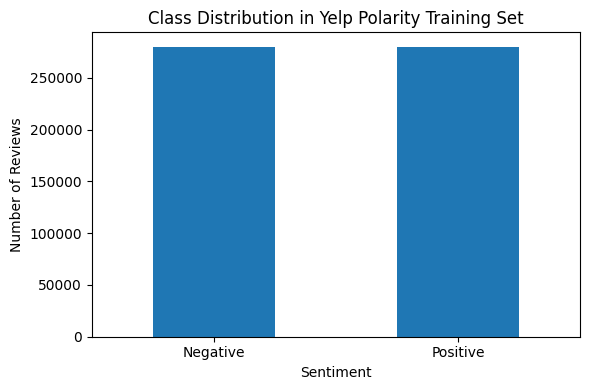

In [9]:
train_class_counts.index = ["Negative", "Positive"]

train_class_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Class Distribution in Yelp Polarity Training Set")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 2.1.3 Review Length Distribution

Review length is measured using the number of whitespace-separated words in
each original review.

Understanding the review length distribution is important because the neural
models require fixed-length batches. The distribution will later be used to
select an appropriate maximum sequence length while balancing information
retention and computational cost.

In [10]:
train_clean["raw_word_count"] = (
    train_clean["text"]
    .str.split()
    .str.len()
)

test_clean["raw_word_count"] = (
    test_clean["text"]
    .str.split()
    .str.len()
)

print("Training review length statistics:")
display(
    train_clean["raw_word_count"].describe()
)

Training review length statistics:


,raw_word_count
count,560000.000000
mean,133.028873
std,122.611613
min,1.000000
25%,51.000000
50%,97.000000
75%,174.000000
max,1052.000000


In [11]:
length_percentiles = (
    train_clean["raw_word_count"]
    .quantile([
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ])
)

print("Training review length percentiles:")
display(length_percentiles)

Training review length percentiles:


,raw_word_count
0.50,97.0
0.75,174.0
0.90,282.0
0.95,372.0
0.99,608.0


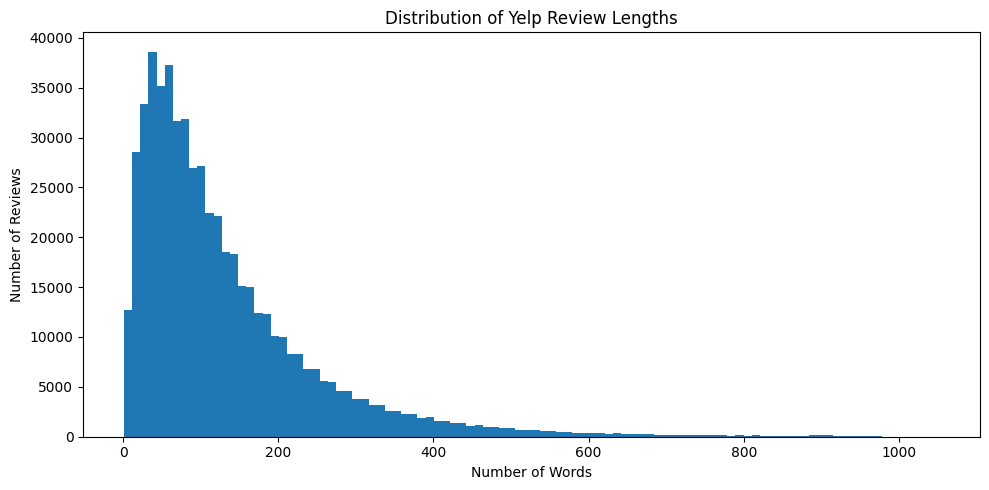

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_clean["raw_word_count"],
    bins=100
)

plt.title("Distribution of Yelp Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

### 2.1.4 Training and Validation Split

The official Yelp training set is divided into training and validation subsets.

A stratified split is used so that the original class distribution is preserved
in both subsets. The official Yelp test set is kept untouched for final model
evaluation.

The same split will be used for all three models to ensure a fair comparison.

In [13]:
train_split, val_split = train_test_split(
    train_clean,
    test_size=0.10,
    random_state=SEED,
    stratify=train_clean["label"]
)

train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)

print("Training subset:", train_split.shape)
print("Validation subset:", val_split.shape)
print("Official test set:", test_clean.shape)

print("\nTraining label distribution:")
print(
    train_split["label"]
    .value_counts(normalize=True)
    .sort_index()
)

print("\nValidation label distribution:")
print(
    val_split["label"]
    .value_counts(normalize=True)
    .sort_index()
)

Training subset: (504000, 3)
Validation subset: (56000, 3)
Official test set: (38000, 3)

Training label distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Validation label distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


### 2.1.5 Text Preprocessing

The following preprocessing steps are applied:

1. Convert text to lowercase.
2. Normalize common English negation contractions.
3. Remove punctuation and special characters.
4. Normalize repeated whitespace.
5. Remove common English stopwords.

Negation and sentiment-relevant words such as `not`, `no`, `never`, and `but`
are intentionally preserved because they can substantially change sentiment.

Stemming or lemmatization is not applied in this experiment. Since the models
use trainable word embeddings and sequence information, aggressive word
normalization may remove useful lexical information. The assignment specifies
stemming or lemmatization only when applicable.

In [14]:
# Preserve words that carry useful sentiment or contrast information
PRESERVE_WORDS = {
    "no",
    "not",
    "nor",
    "never",
    "but",
    "against",
    "very",
    "too"
}

STOP_WORDS = set(ENGLISH_STOP_WORDS) - PRESERVE_WORDS

print("Number of stopwords used:", len(STOP_WORDS))

Number of stopwords used: 310


In [15]:
def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Normalize important negation contractions
    text = re.sub(r"\bcan't\b", "can not", text)
    text = re.sub(r"\bwon't\b", "will not", text)
    text = re.sub(r"n['’]t\b", " not", text)

    # Remove punctuation and special characters
    # Keep letters, digits, and whitespace
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Token-level stopword removal
    tokens = [
        token
        for token in text.split()
        if token not in STOP_WORDS
    ]

    return " ".join(tokens)

In [16]:
example = train_split["text"].iloc[0]

print("Original:")
print(example)

print("\nProcessed:")
print(preprocess_text(example))

Original:
The staff here is very friendly, I guess I am kind of a regular, I stop in about every other day and know most of the employees by name.  There are some long waits sometimes but I see past it because I am treated like a valued customer every time!

Processed:
staff very friendly guess kind regular stop day know employees long waits but past treated like valued customer time


In [17]:
train_split["processed_text"] = (
    train_split["text"]
    .progress_apply(preprocess_text)
)

val_split["processed_text"] = (
    val_split["text"]
    .progress_apply(preprocess_text)
)

test_clean["processed_text"] = (
    test_clean["text"]
    .progress_apply(preprocess_text)
)

  0%|          | 0/504000 [00:00<?, ?it/s]

  0%|          | 0/56000 [00:00<?, ?it/s]

  0%|          | 0/38000 [00:00<?, ?it/s]

In [18]:
comparison = pd.DataFrame({
    "Original": train_split["text"].head(5),
    "Processed": train_split["processed_text"].head(5),
    "Label": train_split["label"].head(5)
})

display(comparison)

,Original,Processed,Label
0,"The staff here is very friendly, I guess I am ...",staff very friendly guess kind regular stop da...,1
1,"Try the Watermelon Agua Fresca, vodka and vani...",try watermelon agua fresca vodka vanilla mint ...,1
2,Yea it still retains its 4 stars and this has ...,yea retains 4 stars confirmed love oatmeal sto...,1
3,We recently had dinner here as a party of 6. F...,recently dinner party 6 restaurant need faceli...,0
4,THE WORST APARTMENT COMPLEX IN THE HISTORY OF ...,worst apartment complex history charlotte wors...,0


In [19]:
train_processed_empty = (
    train_split["processed_text"]
    .str.strip()
    .eq("")
    .sum()
)

val_processed_empty = (
    val_split["processed_text"]
    .str.strip()
    .eq("")
    .sum()
)

test_processed_empty = (
    test_clean["processed_text"]
    .str.strip()
    .eq("")
    .sum()
)

print("Empty processed training reviews:", train_processed_empty)
print("Empty processed validation reviews:", val_processed_empty)
print("Empty processed test reviews:", test_processed_empty)

Empty processed training reviews: 38
Empty processed validation reviews: 2
Empty processed test reviews: 1


In [20]:
# Remove reviews that became empty after preprocessing
train_split = train_split[
    train_split["processed_text"].str.strip() != ""
].reset_index(drop=True)

val_split = val_split[
    val_split["processed_text"].str.strip() != ""
].reset_index(drop=True)

test_clean = test_clean[
    test_clean["processed_text"].str.strip() != ""
].reset_index(drop=True)

print("Training set:", train_split.shape)
print("Validation set:", val_split.shape)
print("Test set:", test_clean.shape)

Training set: (503962, 4)
Validation set: (55998, 4)
Test set: (37999, 4)


A small number of reviews became empty after preprocessing because all of their
tokens were removed during normalization and stopword filtering. These entries
were removed before tokenization because they contain no usable textual input
for the classifiers.

### 2.1.6 Tokenization

A word-level tokenizer is used after text preprocessing.

Each processed review is split into individual word tokens. A vocabulary is then
constructed using only the training subset to prevent information from the
validation or test sets from influencing the model representation.

Two special tokens are included:

- `<PAD>` for sequence padding
- `<UNK>` for words that are not included in the training vocabulary

In [21]:
def tokenize(text):
    return text.split()

In [22]:
sample_text = train_split["processed_text"].iloc[0]

print("Processed review:")
print(sample_text)

print("\nTokens:")
print(tokenize(sample_text)[:30])

Processed review:
staff very friendly guess kind regular stop day know employees long waits but past treated like valued customer time

Tokens:
['staff', 'very', 'friendly', 'guess', 'kind', 'regular', 'stop', 'day', 'know', 'employees', 'long', 'waits', 'but', 'past', 'treated', 'like', 'valued', 'customer', 'time']


In [23]:
MAX_VOCAB_SIZE = 50_000
MIN_FREQ = 2

token_counter = Counter()

for text in tqdm(
    train_split["processed_text"],
    desc="Building vocabulary"
):
    token_counter.update(tokenize(text))

print("Total unique tokens before filtering:",
      len(token_counter))

Building vocabulary:   0%|          | 0/503962 [00:00<?, ?it/s]

Total unique tokens before filtering: 212436


In [24]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

itos = [
    PAD_TOKEN,
    UNK_TOKEN
]

for token, frequency in token_counter.most_common():

    if frequency < MIN_FREQ:
        break

    if len(itos) >= MAX_VOCAB_SIZE:
        break

    itos.append(token)

stoi = {
    token: index
    for index, token in enumerate(itos)
}

PAD_IDX = stoi[PAD_TOKEN]
UNK_IDX = stoi[UNK_TOKEN]

VOCAB_SIZE = len(itos)

print("Final vocabulary size:", VOCAB_SIZE)
print("PAD index:", PAD_IDX)
print("UNK index:", UNK_IDX)

Final vocabulary size: 50000
PAD index: 0
UNK index: 1


In [25]:
print("Most common training tokens:")

for token, count in token_counter.most_common(20):
    print(f"{token:<15} {count}")

Most common training tokens:
not             944747
n               738091
but             516454
s               398705
food            296922
place           290513
good            270972
like            236762
just            232818
very            213727
did             200808
time            194870
great           189429
service         187775
no              171306
really          152461
got             120796
ni              118604
ve              109964
m               109838


### 2.1.7 Numerical Encoding

Neural networks cannot directly process text tokens. Each word token is therefore
mapped to its corresponding integer vocabulary index.

Words that do not appear in the training vocabulary are mapped to the `<UNK>`
token.

In [26]:
def numericalize(text):
    tokens = tokenize(text)

    return [
        stoi.get(token, UNK_IDX)
        for token in tokens
    ]

In [27]:
sample_text = train_split["processed_text"].iloc[0]
sample_tokens = tokenize(sample_text)
sample_ids = numericalize(sample_text)

print("Tokens:")
print(sample_tokens[:20])

print("\nToken IDs:")
print(sample_ids[:20])

Tokens:
['staff', 'very', 'friendly', 'guess', 'kind', 'regular', 'stop', 'day', 'know', 'employees', 'long', 'waits', 'but', 'past', 'treated', 'like', 'valued', 'customer', 'time']

Token IDs:
[47, 11, 67, 287, 175, 385, 311, 59, 35, 403, 81, 4395, 4, 372, 822, 9, 7598, 101, 13]


### 2.1.8 Sequence Length After Preprocessing

The token-length distribution is recalculated after preprocessing because the
removal of stopwords and punctuation reduces sequence length.

These statistics will be used to choose the final padding and truncation length
for the neural classifiers.

In [28]:
train_split["token_count"] = (
    train_split["processed_text"]
    .str.split()
    .str.len()
)

processed_length_percentiles = (
    train_split["token_count"]
    .quantile([
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ])
)

print("Processed review length statistics:")
display(train_split["token_count"].describe())

print("\nProcessed review length percentiles:")
display(processed_length_percentiles)


Processed review length statistics:


,token_count
count,503962.000000
mean,67.742996
std,61.889454
min,1.000000
25%,26.000000
50%,49.000000
75%,88.000000
max,763.000000



Processed review length percentiles:


,token_count
0.50,49.0
0.75,88.0
0.90,143.0
0.95,189.0
0.99,308.0


### Maximum Sequence Length

After preprocessing, the median review length is 49 tokens, while the 90th
and 95th percentiles are 143 and 189 tokens, respectively.

Based on this distribution, I set the maximum sequence length to **192 tokens**.
This preserves approximately 95% of the reviews without truncation while
avoiding the additional padding and computational cost of using a substantially
larger sequence length.

Reviews longer than 192 tokens will be truncated, and shorter reviews will be
padded to the same length during batching.

In [29]:
MAX_LEN = 192

coverage = (
    train_split["token_count"] <= MAX_LEN
).mean() * 100

truncation_rate = 100 - coverage

print(f"Maximum sequence length: {MAX_LEN}")
print(f"Reviews covered without truncation: {coverage:.2f}%")
print(f"Reviews requiring truncation: {truncation_rate:.2f}%")

Maximum sequence length: 192
Reviews covered without truncation: 95.27%
Reviews requiring truncation: 4.73%


### 2.1.9 Trainable Embeddings From Scratch

No pretrained word embeddings are used in this task.

Each model uses a randomly initialized PyTorch `Embedding` layer to convert
token IDs into dense vector representations. The embedding weights are learned
jointly with the sentiment classifier during training.

This ensures that the textual representations are learned entirely from the
Yelp Polarity training data.

For the initial model configuration, the embedding dimension is set to 128.

In [30]:
EMBEDDING_DIM = 128

embedding_layer = nn.Embedding(
    num_embeddings=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    padding_idx=PAD_IDX
)

print(embedding_layer)
print("Vocabulary size:", VOCAB_SIZE)
print("Embedding dimension:", EMBEDDING_DIM)
print("Embedding weight shape:", embedding_layer.weight.shape)
print("Embedding weights trainable:", embedding_layer.weight.requires_grad)

Embedding(50000, 128, padding_idx=0)
Vocabulary size: 50000
Embedding dimension: 128
Embedding weight shape: torch.Size([50000, 128])
Embedding weights trainable: True


### 2.1.10 Save Processed Data and Preprocessing Artifacts

The processed training, validation, and test datasets are saved to Google Drive
for reuse during model training.

For reproducibility, the vocabulary and preprocessing configuration are also
exported as separate artifacts. These small files can be included in the GitHub
repository together with the notebook and experiment results.

In [31]:
train_split["token_count"] = (
    train_split["processed_text"]
    .str.split()
    .str.len()
)

val_split["token_count"] = (
    val_split["processed_text"]
    .str.split()
    .str.len()
)

test_clean["token_count"] = (
    test_clean["processed_text"]
    .str.split()
    .str.len()
)

print("Train columns:", train_split.columns.tolist())
print("Validation columns:", val_split.columns.tolist())
print("Test columns:", test_clean.columns.tolist())

Train columns: ['text', 'label', 'raw_word_count', 'processed_text', 'token_count']
Validation columns: ['text', 'label', 'raw_word_count', 'processed_text', 'token_count']
Test columns: ['text', 'label', 'raw_word_count', 'processed_text', 'token_count']


In [32]:
train_to_save = train_split[
    [
        "text",
        "processed_text",
        "label",
        "token_count"
    ]
].copy()

val_to_save = val_split[
    [
        "text",
        "processed_text",
        "label",
        "token_count"
    ]
].copy()

test_to_save = test_clean[
    [
        "text",
        "processed_text",
        "label",
        "token_count"
    ]
].copy()

print("Train:", train_to_save.shape)
print("Validation:", val_to_save.shape)
print("Test:", test_to_save.shape)

Train: (503962, 4)
Validation: (55998, 4)
Test: (37999, 4)


In [33]:
from pathlib import Path
import json

DRIVE_PROCESSED_DIR = Path(
    "/content/drive/MyDrive/"
    "DATA266_Pair41_Lab1/"
    "task2_sentiment/"
    "Yuyao_Ding/"
    "data_processed"
)

DRIVE_PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Google Drive directory:")
print(DRIVE_PROCESSED_DIR)

Google Drive directory:
/content/drive/MyDrive/DATA266_Pair41_Lab1/task2_sentiment/Yuyao_Ding/data_processed


In [34]:
train_to_save.to_parquet(
    DRIVE_PROCESSED_DIR / "train_processed.parquet",
    index=False
)

val_to_save.to_parquet(
    DRIVE_PROCESSED_DIR / "val_processed.parquet",
    index=False
)

test_to_save.to_parquet(
    DRIVE_PROCESSED_DIR / "test_processed.parquet",
    index=False
)

print("Processed datasets saved to Google Drive.")

Processed datasets saved to Google Drive.


In [35]:
print("Saved processed datasets:\n")

for file in sorted(DRIVE_PROCESSED_DIR.glob("*.parquet")):
    size_mb = file.stat().st_size / (1024 ** 2)
    print(f"{file.name:<30} {size_mb:.2f} MB")

Saved processed datasets:

test_processed.parquet         25.75 MB
train_processed.parquet        347.88 MB
val_processed.parquet          38.75 MB


In [36]:
ARTIFACT_DIR = Path(
    "/content/task2_artifacts"
)

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Artifact directory:")
print(ARTIFACT_DIR)

Artifact directory:
/content/task2_artifacts


In [37]:
vocab_data = {
    "itos": itos,
    "pad_token": PAD_TOKEN,
    "unk_token": UNK_TOKEN,
    "pad_idx": PAD_IDX,
    "unk_idx": UNK_IDX,
    "vocab_size": VOCAB_SIZE
}

with open(
    ARTIFACT_DIR / "vocab.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        vocab_data,
        f,
        ensure_ascii=False,
        indent=2
    )

print("Vocabulary exported.")

Vocabulary exported.


In [38]:
preprocessing_config = {
    "seed": SEED,

    "dataset": "Yelp Polarity",

    "split": {
        "validation_fraction": 0.10,
        "stratified": True
    },

    "text_processing": {
        "lowercase": True,
        "remove_punctuation": True,
        "remove_special_characters": True,
        "stopword_removal": True,
        "stemming": False,
        "lemmatization": False,
        "preserve_negation": True,
        "preserved_words": sorted(PRESERVE_WORDS)
    },

    "tokenization": {
        "type": "word_level"
    },

    "vocabulary": {
        "max_vocab_size": MAX_VOCAB_SIZE,
        "min_frequency": MIN_FREQ,
        "final_vocab_size": VOCAB_SIZE
    },

    "sequence": {
        "max_length": MAX_LEN
    },

    "embedding": {
        "dimension": EMBEDDING_DIM,
        "pretrained": False,
        "trainable": True
    },

    "labels": {
        "0": "negative",
        "1": "positive"
    }
}

with open(
    ARTIFACT_DIR / "preprocessing_config.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        preprocessing_config,
        f,
        indent=2
    )

print("Preprocessing configuration exported.")

Preprocessing configuration exported.


In [39]:
print("Exported artifacts:\n")

for file in sorted(ARTIFACT_DIR.iterdir()):
    size_kb = file.stat().st_size / 1024
    print(f"{file.name:<35} {size_kb:.2f} KB")

Exported artifacts:

preprocessing_config.json           0.82 KB
vocab.json                          730.51 KB


### 2.1 Preprocessing Summary

The Yelp Polarity dataset was inspected for review length, class distribution,
class balance, missing values, and malformed entries.

The original training data was split into stratified training and validation
subsets, while the official test set was reserved for final evaluation.

The review text was lowercased, cleaned of punctuation and special characters,
and filtered using English stopwords while preserving important negation and
sentiment-related words. Reviews that became empty after preprocessing were
removed.

A word-level vocabulary of up to 50,000 tokens was built using only the training
subset. The maximum sequence length was set to 192 tokens based on the observed
review length distribution.

All word embeddings are randomly initialized and learned from scratch during
model training. No pretrained embeddings or pretrained language models are used.

The processed datasets were saved to Google Drive, while the vocabulary and
preprocessing configuration were exported separately for reproducibility.

## 2.2 Model Training and Evaluation

Three sentiment classification models are trained and compared using the same
preprocessed Yelp Polarity dataset.

The models are designed to progressively introduce more expressive ways of
representing review text:

1. **Baseline — Mean-Pooled Embedding Classifier**
   - Uses trainable word embeddings followed by mean pooling.
   - Provides a simple reference model with minimal sequence modeling.

2. **Experimental Model 1 — TextCNN**
   - Applies one-dimensional convolutional filters over word embeddings.
   - Captures local phrase and n-gram patterns that may be useful for sentiment
     classification.

3. **Experimental Model 2 — Bidirectional LSTM**
   - Processes the review in both forward and backward directions.
   - Captures sequential and contextual information that is not represented by
     the baseline model.

All three models use word embeddings initialized randomly and learned from
scratch. The same train, validation, and test splits are used for a fair
comparison.

### 2.2.1 PyTorch Dataset and DataLoader

The processed Yelp reviews are converted into fixed-length sequences of token IDs
for PyTorch model training.

Each review is:

1. tokenized using the word-level tokenizer defined during preprocessing,
2. converted to integer IDs using the training vocabulary,
3. truncated to a maximum length of 192 tokens if necessary, and
4. padded with the `<PAD>` token when shorter than 192 tokens.

The same encoded dataset and data splits are used for all three models to ensure
a fair comparison.

In [40]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [41]:
def encode_text(text, max_len=MAX_LEN):
    tokens = text.split()

    token_ids = [
        stoi.get(token, UNK_IDX)
        for token in tokens
    ]

    # Truncate long reviews
    token_ids = token_ids[:max_len]

    # Pad short reviews
    if len(token_ids) < max_len:
        token_ids += [
            PAD_IDX
        ] * (max_len - len(token_ids))

    return token_ids

In [42]:
sample_text = train_split["processed_text"].iloc[0]

sample_ids = encode_text(sample_text)

print("Processed text:")
print(sample_text[:500])

print("\nFirst 30 token IDs:")
print(sample_ids[:30])

print("\nEncoded sequence length:")
print(len(sample_ids))

Processed text:
staff very friendly guess kind regular stop day know employees long waits but past treated like valued customer time

First 30 token IDs:
[47, 11, 67, 287, 175, 385, 311, 59, 35, 403, 81, 4395, 4, 372, 822, 9, 7598, 101, 13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Encoded sequence length:
192


#### Custom PyTorch Dataset

A custom PyTorch `Dataset` is used to encode each review and return:

- a fixed-length tensor of token IDs, and
- the corresponding binary sentiment label.

The labels are stored as floating-point values because the classifiers will use
a single output logit together with binary cross-entropy loss.

In [43]:
from torch.utils.data import Dataset, DataLoader


class YelpDataset(Dataset):
    def __init__(self, dataframe, max_len=MAX_LEN):
        self.texts = dataframe["processed_text"].tolist()
        self.labels = dataframe["label"].to_numpy()
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        input_ids = encode_text(
            text,
            max_len=self.max_len
        )

        input_ids = torch.tensor(
            input_ids,
            dtype=torch.long
        )

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        return input_ids, label

In [44]:
train_dataset = YelpDataset(
    train_split,
    max_len=MAX_LEN
)

val_dataset = YelpDataset(
    val_split,
    max_len=MAX_LEN
)

test_dataset = YelpDataset(
    test_clean,
    max_len=MAX_LEN
)

print("Training examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Test examples:", len(test_dataset))

Training examples: 503962
Validation examples: 55998
Test examples: 37999


In [45]:
sample_input_ids, sample_label = train_dataset[0]

print("Input tensor shape:", sample_input_ids.shape)
print("Label tensor shape:", sample_label.shape)

print("\nFirst 30 token IDs:")
print(sample_input_ids[:30])

print("\nLabel:")
print(sample_label)

Input tensor shape: torch.Size([192])
Label tensor shape: torch.Size([])

First 30 token IDs:
tensor([  47,   11,   67,  287,  175,  385,  311,   59,   35,  403,   81, 4395,
           4,  372,  822,    9, 7598,  101,   13,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0])

Label:
tensor(1.)


In [46]:
non_pad_tokens = (
    sample_input_ids != PAD_IDX
).sum().item()

padding_tokens = (
    sample_input_ids == PAD_IDX
).sum().item()

print("Non-padding tokens:", non_pad_tokens)
print("Padding tokens:", padding_tokens)
print(
    "Total:",
    non_pad_tokens + padding_tokens
)

Non-padding tokens: 19
Padding tokens: 173
Total: 192


#### DataLoaders

PyTorch `DataLoader` objects are created for minibatch training and evaluation.

The training loader shuffles examples at the beginning of each epoch, while
validation and test loaders preserve a deterministic order.

A fixed random seed is used to improve reproducibility across experiments.

In [47]:
BATCH_SIZE = 256

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

In [48]:
# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

In [49]:
# Batch Sanity Check
batch_input_ids, batch_labels = next(
    iter(train_loader)
)

print("Input batch shape:", batch_input_ids.shape)
print("Label batch shape:", batch_labels.shape)

print("Input dtype:", batch_input_ids.dtype)
print("Label dtype:", batch_labels.dtype)

print("\nFirst 10 labels:")
print(batch_labels[:10])

Input batch shape: torch.Size([256, 192])
Label batch shape: torch.Size([256])
Input dtype: torch.int64
Label dtype: torch.float32

First 10 labels:
tensor([0., 0., 0., 1., 0., 0., 0., 1., 0., 1.])


In [50]:
# Check Token Range
print(
    "Minimum token ID:",
    batch_input_ids.min().item()
)

print(
    "Maximum token ID:",
    batch_input_ids.max().item()
)

print(
    "Vocabulary size:",
    VOCAB_SIZE
)

assert batch_input_ids.min() >= 0
assert batch_input_ids.max() < VOCAB_SIZE

print("\nToken ID check passed.")

Minimum token ID: 0
Maximum token ID: 49474
Vocabulary size: 50000

Token ID check passed.


#### Dataset and DataLoader Summary

All reviews are represented as fixed-length sequences of 192 word-token IDs.

The same vocabulary, maximum sequence length, and train/validation/test splits
are shared across all three models. Training batches are shuffled, while
validation and test batches remain deterministic.

This shared data pipeline ensures that differences in model performance are
primarily attributable to model architecture rather than differences in data
preparation.

### 2.2.2 Baseline Model — Mean-Pooled Embedding Classifier

The baseline model uses a simple mean-pooled word embedding representation.

Architecture:

**Token IDs → Trainable Embedding → Masked Mean Pooling → Dropout → Linear Output**

Each token is mapped to a 128-dimensional embedding learned from scratch.
The embeddings of all non-padding tokens in a review are averaged to produce
a single review representation.

A dropout layer is applied before the final linear layer, which outputs one
logit for binary sentiment classification.

This model serves as a simple baseline because it does not explicitly model
word order or contextual dependencies. Its performance provides a reference
for evaluating whether the TextCNN and BiLSTM models benefit from more
expressive sequence modeling.

In [51]:
class MeanPoolClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        pad_idx,
        dropout=0.3
    ):
        super().__init__()

        self.pad_idx = pad_idx

        # Trainable embeddings learned from scratch
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )

        self.dropout = nn.Dropout(dropout)

        # One output logit for binary classification
        self.fc = nn.Linear(
            embedding_dim,
            1
        )

    def forward(self, input_ids):
        # input_ids:
        # [batch_size, sequence_length]

        embedded = self.embedding(input_ids)
        # [batch_size, sequence_length, embedding_dim]

        # Mask padding tokens
        mask = (
            input_ids != self.pad_idx
        ).unsqueeze(-1).float()
        # [batch_size, sequence_length, 1]

        # Sum only valid token embeddings
        summed_embeddings = (
            embedded * mask
        ).sum(dim=1)
        # [batch_size, embedding_dim]

        # Number of valid tokens in each review
        token_counts = (
            mask.sum(dim=1)
            .clamp(min=1)
        )
        # [batch_size, 1]

        # Mean pooling
        pooled = (
            summed_embeddings / token_counts
        )
        # [batch_size, embedding_dim]

        pooled = self.dropout(pooled)

        logits = self.fc(pooled).squeeze(1)
        # [batch_size]

        return logits

In [52]:
# Instantiate Baseline
BASELINE_DROPOUT = 0.3

baseline_model = MeanPoolClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    pad_idx=PAD_IDX,
    dropout=BASELINE_DROPOUT
)

baseline_model = baseline_model.to(device)

print(baseline_model)

MeanPoolClassifier(
  (embedding): Embedding(50000, 128, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


#### Baseline Hyperparameters

The baseline uses the following initial configuration:

| Hyperparameter | Value |
|---|---:|
| Vocabulary size | 50,000 |
| Embedding dimension | 128 |
| Maximum sequence length | 192 |
| Dropout | 0.30 |
| Output dimension | 1 |
| Pretrained embeddings | No |

In [53]:
# Parameter Count
def count_parameters(model):
    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return total_params, trainable_params


baseline_total_params, baseline_trainable_params = (
    count_parameters(baseline_model)
)

print(
    f"Total parameters: "
    f"{baseline_total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{baseline_trainable_params:,}"
)

Total parameters: 6,400,129
Trainable parameters: 6,400,129


#### Binary Classification Objective

The model outputs a single raw logit for each review.

`BCEWithLogitsLoss` is used as the training objective. This loss combines the
sigmoid operation and binary cross-entropy calculation in a numerically stable
implementation.

Therefore, no sigmoid activation is applied inside the model during training.
Sigmoid is only applied when converting logits into probabilities for
evaluation.

In [56]:
baseline_criterion = nn.BCEWithLogitsLoss()

print(baseline_criterion)

BCEWithLogitsLoss()


In [57]:
baseline_model.eval()

with torch.no_grad():
    sample_inputs = batch_input_ids.to(device)
    sample_labels = batch_labels.to(device)

    sample_logits = baseline_model(
        sample_inputs
    )

print("Input shape:")
print(sample_inputs.shape)

print("\nLogit shape:")
print(sample_logits.shape)

print("\nLabel shape:")
print(sample_labels.shape)

Input shape:
torch.Size([256, 192])

Logit shape:
torch.Size([256])

Label shape:
torch.Size([256])


In [58]:
with torch.no_grad():
    sample_loss = baseline_criterion(
        sample_logits,
        sample_labels
    )

print(
    f"Smoke-test loss: "
    f"{sample_loss.item():.4f}"
)

Smoke-test loss: 0.6873


In [59]:
with torch.no_grad():
    sample_probabilities = torch.sigmoid(
        sample_logits
    )

    sample_predictions = (
        sample_probabilities >= 0.5
    ).long()

print("First 10 probabilities:")
print(
    sample_probabilities[:10]
    .cpu()
)

print("\nFirst 10 predictions:")
print(
    sample_predictions[:10]
    .cpu()
)

print("\nFirst 10 true labels:")
print(
    sample_labels[:10]
    .long()
    .cpu()
)

First 10 probabilities:
tensor([0.5366, 0.5052, 0.5170, 0.5301, 0.5203, 0.5193, 0.5118, 0.5124, 0.4583,
        0.4883])

First 10 predictions:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 0, 0])

First 10 true labels:
tensor([0, 0, 0, 1, 0, 0, 0, 1, 0, 1])


#### Baseline Model Summary

The baseline converts each review into the mean of its trainable word
embeddings and uses this representation for binary sentiment classification.

Its main advantage is simplicity and computational efficiency. However,
mean pooling removes explicit word-order information. For example, reviews
containing similar words in different contexts may receive similar
representations.

This limitation provides motivation for the experimental models, which will
introduce local feature extraction and sequential context modeling.

### 2.2.3 Baseline Model Training

The baseline model is trained using binary cross-entropy with logits and the
Adam optimizer.

The validation set is evaluated after each epoch. The model checkpoint with the
lowest validation loss is retained for final evaluation.

Training statistics recorded for each epoch include:

- training loss,
- validation loss,
- training accuracy,
- validation accuracy,
- training time, and
- training throughput (examples per second).

The final run also records the hardware configuration and peak GPU memory usage
for reproducibility.

In [60]:
BASELINE_LR = 1e-3
BASELINE_EPOCHS = 5
BASELINE_PATIENCE = 2

print("Baseline training configuration:")
print(f"Learning rate: {BASELINE_LR}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Maximum epochs: {BASELINE_EPOCHS}")
print(f"Early stopping patience: {BASELINE_PATIENCE}")

Baseline training configuration:
Learning rate: 0.001
Batch size: 256
Maximum epochs: 5
Early stopping patience: 2


#### Baseline Training Hyperparameters

| Hyperparameter | Value |
|---|---:|
| Optimizer | Adam |
| Learning rate | 0.001 |
| Loss function | BCEWithLogitsLoss |
| Batch size | 256 |
| Maximum epochs | 5 |
| Early stopping patience | 2 |
| Dropout | 0.30 |
| Embedding dimension | 128 |
| Maximum sequence length | 192 |

In [61]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

baseline_model = MeanPoolClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    pad_idx=PAD_IDX,
    dropout=BASELINE_DROPOUT
).to(device)

baseline_criterion = nn.BCEWithLogitsLoss()

baseline_optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=BASELINE_LR
)

print(baseline_model)

MeanPoolClassifier(
  (embedding): Embedding(50000, 128, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


Hardware Information

In [62]:
import os
import platform
import time
from datetime import datetime

In [63]:
def get_cpu_name():
    try:
        with open("/proc/cpuinfo", "r") as f:
            for line in f:
                if "model name" in line:
                    return line.split(":", 1)[1].strip()
    except Exception:
        pass

    return platform.processor()


hardware_info = {
    "device": str(device),
    "cpu": get_cpu_name(),
    "cpu_count": os.cpu_count(),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "None"
    ),
    "pytorch_version": torch.__version__
}

hardware_info

{'device': 'cpu',
 'cpu': 'Intel(R) Xeon(R) CPU @ 2.20GHz',
 'cpu_count': 2,
 'gpu': 'None',
 'pytorch_version': '2.11.0+cpu'}

In [64]:
# Create Baseline Run Directory
BASELINE_RUN_DIR = (
    DRIVE_PROCESSED_DIR.parent
    / "baseline_mean_pool"
)

BASELINE_RUN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RUN_ID = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

RAW_LOG_PATH = (
    BASELINE_RUN_DIR
    / f"baseline_raw_log_{RUN_ID}.txt"
)

CHECKPOINT_PATH = (
    BASELINE_RUN_DIR
    / f"baseline_best_{RUN_ID}.pt"
)

HISTORY_PATH = (
    BASELINE_RUN_DIR
    / f"baseline_history_{RUN_ID}.csv"
)

HARDWARE_PATH = (
    BASELINE_RUN_DIR
    / f"baseline_hardware_{RUN_ID}.json"
)

print(BASELINE_RUN_DIR)

/content/drive/MyDrive/DATA266_Pair41_Lab1/task2_sentiment/Yuyao_Ding/baseline_mean_pool


In [65]:
with open(
    HARDWARE_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        hardware_info,
        f,
        indent=2
    )

print("Hardware information saved.")

Hardware information saved.


#### Training and Validation Functions

The training loop performs forward propagation, loss calculation,
backpropagation, and parameter updates for each minibatch.

The validation loop runs without gradient computation and does not update model
parameters.

A prediction threshold of 0.5 is applied after the sigmoid transformation when
computing classification accuracy.

In [66]:
# Train One Epoch
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    start_time = time.perf_counter()

    for input_ids, labels in loader:

        input_ids = input_ids.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(input_ids)

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        probabilities = torch.sigmoid(
            logits
        )

        predictions = (
            probabilities >= 0.5
        ).float()

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size

    elapsed = (
        time.perf_counter()
        - start_time
    )

    average_loss = (
        running_loss / total
    )

    accuracy = (
        correct / total
    )

    examples_per_second = (
        total / elapsed
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "time_seconds": elapsed,
        "examples_per_second": examples_per_second
    }

In [67]:
# Validation Function
def evaluate_epoch(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    start_time = time.perf_counter()

    with torch.no_grad():

        for input_ids, labels in loader:

            input_ids = input_ids.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            logits = model(input_ids)

            loss = criterion(
                logits,
                labels
            )

            batch_size = labels.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            probabilities = torch.sigmoid(
                logits
            )

            predictions = (
                probabilities >= 0.5
            ).float()

            correct += (
                predictions == labels
            ).sum().item()

            total += batch_size

    elapsed = (
        time.perf_counter()
        - start_time
    )

    return {
        "loss": running_loss / total,
        "accuracy": correct / total,
        "time_seconds": elapsed
    }

In [68]:
# Training Loop
history = []

best_val_loss = float("inf")
patience_counter = 0

total_training_start = time.perf_counter()

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()


with open(
    RAW_LOG_PATH,
    "w",
    encoding="utf-8"
) as log_file:

    log_file.write(
        "Baseline Mean-Pooled Embedding Classifier\n"
    )

    log_file.write(
        f"Run ID: {RUN_ID}\n"
    )

    log_file.write(
        f"Device: {hardware_info['device']}\n"
    )

    log_file.write(
        f"CPU: {hardware_info['cpu']}\n"
    )

    log_file.write(
        f"GPU: {hardware_info['gpu']}\n"
    )

    log_file.write(
        f"Batch size: {BATCH_SIZE}\n"
    )

    log_file.write(
        f"Learning rate: {BASELINE_LR}\n"
    )

    log_file.write(
        f"Maximum epochs: {BASELINE_EPOCHS}\n\n"
    )

    for epoch in range(
        1,
        BASELINE_EPOCHS + 1
    ):

        train_metrics = train_one_epoch(
            baseline_model,
            train_loader,
            baseline_criterion,
            baseline_optimizer,
            device
        )

        val_metrics = evaluate_epoch(
            baseline_model,
            val_loader,
            baseline_criterion,
            device
        )

        epoch_record = {
            "epoch": epoch,

            "train_loss":
                train_metrics["loss"],

            "train_accuracy":
                train_metrics["accuracy"],

            "val_loss":
                val_metrics["loss"],

            "val_accuracy":
                val_metrics["accuracy"],

            "train_time_seconds":
                train_metrics["time_seconds"],

            "train_examples_per_second":
                train_metrics[
                    "examples_per_second"
                ],

            "val_time_seconds":
                val_metrics["time_seconds"]
        }

        history.append(
            epoch_record
        )

        log_line = (
            f"Epoch {epoch:02d} | "
            f"Train Loss: "
            f"{train_metrics['loss']:.4f} | "
            f"Train Acc: "
            f"{train_metrics['accuracy']:.4f} | "
            f"Val Loss: "
            f"{val_metrics['loss']:.4f} | "
            f"Val Acc: "
            f"{val_metrics['accuracy']:.4f} | "
            f"Examples/sec: "
            f"{train_metrics['examples_per_second']:.2f}"
        )

        print(log_line)

        log_file.write(
            log_line + "\n"
        )

        # Save best validation checkpoint
        if (
            val_metrics["loss"]
            < best_val_loss
        ):

            best_val_loss = (
                val_metrics["loss"]
            )

            patience_counter = 0

            torch.save(
                {
                    "epoch": epoch,

                    "model_state_dict":
                        baseline_model.state_dict(),

                    "optimizer_state_dict":
                        baseline_optimizer.state_dict(),

                    "val_loss":
                        best_val_loss,

                    "vocab_size":
                        VOCAB_SIZE,

                    "embedding_dim":
                        EMBEDDING_DIM,

                    "max_len":
                        MAX_LEN,

                    "dropout":
                        BASELINE_DROPOUT,

                    "learning_rate":
                        BASELINE_LR,

                    "batch_size":
                        BATCH_SIZE,

                    "seed":
                        SEED
                },
                CHECKPOINT_PATH
            )

            log_file.write(
                "Best checkpoint updated.\n"
            )

        else:

            patience_counter += 1

            log_file.write(
                f"No improvement. "
                f"Patience: "
                f"{patience_counter}/"
                f"{BASELINE_PATIENCE}\n"
            )

        log_file.flush()

        if (
            patience_counter
            >= BASELINE_PATIENCE
        ):

            stop_message = (
                f"Early stopping after "
                f"epoch {epoch}."
            )

            print(stop_message)

            log_file.write(
                stop_message + "\n"
            )

            break

Epoch 01 | Train Loss: 0.2978 | Train Acc: 0.8837 | Val Loss: 0.2053 | Val Acc: 0.9233 | Examples/sec: 2302.53
Epoch 02 | Train Loss: 0.2012 | Train Acc: 0.9250 | Val Loss: 0.1931 | Val Acc: 0.9282 | Examples/sec: 2612.65


KeyboardInterrupt: 

In [ ]:
# Training Summary
total_training_time = (
    time.perf_counter()
    - total_training_start
)

if torch.cuda.is_available():

    peak_memory_mb = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 2)
    )

else:
    peak_memory_mb = None


print(
    f"Total training wall time: "
    f"{total_training_time:.2f} seconds"
)

if peak_memory_mb is not None:
    print(
        f"Peak GPU memory: "
        f"{peak_memory_mb:.2f} MB"
    )

In [ ]:
# Save Training History
history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

display(history_df)

In [ ]:
# Complement Training Summary to Raw Log
with open(
    RAW_LOG_PATH,
    "a",
    encoding="utf-8"
) as log_file:

    log_file.write(
        "\n=== Training Summary ===\n"
    )

    log_file.write(
        f"Total wall time: "
        f"{total_training_time:.2f} seconds\n"
    )

    if peak_memory_mb is not None:

        log_file.write(
            f"Peak GPU memory: "
            f"{peak_memory_mb:.2f} MB\n"
        )

    log_file.write(
        f"Best validation loss: "
        f"{best_val_loss:.6f}\n"
    )

#### Training Curves

Training and validation loss curves are used to inspect model convergence and
possible overfitting.

Accuracy curves are also plotted to compare learning behavior on the training
and validation sets.

In [ ]:
# Loss Curve
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Accuracy Curve
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Reload Best Checkpoint
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

baseline_model.load_state_dict(
    checkpoint["model_state_dict"]
)

baseline_model.eval()

print(
    "Loaded best checkpoint from epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation loss:",
    checkpoint["val_loss"]
)

#### Baseline Training Summary

The baseline model was trained using Adam and binary cross-entropy with logits.

Model performance was monitored on the validation set after each epoch, and the
checkpoint with the lowest validation loss was retained for final evaluation.

Raw training logs, epoch-level history, hardware information, and the best model
checkpoint were saved to preserve the experimental evidence and support
reproducibility.

### 2.2.4 Baseline Model Evaluation

The best baseline checkpoint is evaluated on the held-out Yelp Polarity test set.

The evaluation includes:

- accuracy,
- precision, recall, and F1-score,
- macro, micro, and weighted averages,
- confusion matrix,
- ROC-AUC,
- PR-AUC,
- Matthews correlation coefficient (MCC),
- Brier score,
- expected calibration error (ECE), and
- 95% bootstrap confidence intervals for accuracy, macro-F1, and MCC.

The evaluation functions defined in this section will also be reused for the two
experimental models to ensure consistent metric computation.

In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss,
    f1_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def collect_predictions(
    model,
    loader,
    device
):
    model.eval()

    all_labels = []
    all_probabilities = []

    with torch.no_grad():

        for input_ids, labels in loader:

            input_ids = input_ids.to(
                device,
                non_blocking=True
            )

            logits = model(input_ids)

            probabilities = torch.sigmoid(
                logits
            )

            all_labels.append(
                labels.cpu().numpy()
            )

            all_probabilities.append(
                probabilities.cpu().numpy()
            )

    y_true = np.concatenate(
        all_labels
    ).astype(int)

    y_prob = np.concatenate(
        all_probabilities
    )

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    return y_true, y_prob, y_pred

In [ ]:
baseline_y_true, baseline_y_prob, baseline_y_pred = (
    collect_predictions(
        baseline_model,
        test_loader,
        device
    )
)

print("Number of test examples:", len(baseline_y_true))

print(
    "Positive prediction rate:",
    baseline_y_pred.mean()
)

#### Classification Metrics

Precision, recall, and F1-score are reported using macro, micro, and weighted
averaging.

Macro averaging treats both sentiment classes equally, while weighted averaging
accounts for the number of examples in each class. Micro averaging aggregates
all predictions before computing the metric.

In [70]:
def classification_metrics(
    y_true,
    y_pred,
    y_prob
):
    metrics = {}

    metrics["accuracy"] = accuracy_score(
        y_true,
        y_pred
    )

    for average in [
        "macro",
        "micro",
        "weighted"
    ]:

        precision, recall, f1, _ = (
            precision_recall_fscore_support(
                y_true,
                y_pred,
                average=average,
                zero_division=0
            )
        )

        metrics[f"precision_{average}"] = precision
        metrics[f"recall_{average}"] = recall
        metrics[f"f1_{average}"] = f1

    metrics["roc_auc"] = roc_auc_score(
        y_true,
        y_prob
    )

    metrics["pr_auc"] = average_precision_score(
        y_true,
        y_prob
    )

    metrics["mcc"] = matthews_corrcoef(
        y_true,
        y_pred
    )

    metrics["brier_score"] = brier_score_loss(
        y_true,
        y_prob
    )

    return metrics

In [ ]:
baseline_metrics = classification_metrics(
    baseline_y_true,
    baseline_y_pred,
    baseline_y_prob
)

baseline_metrics_df = pd.DataFrame(
    baseline_metrics.items(),
    columns=[
        "Metric",
        "Value"
    ]
)

display(
    baseline_metrics_df.round(4)
)

#### Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified
negative and positive reviews.

In [ ]:
baseline_cm = confusion_matrix(
    baseline_y_true,
    baseline_y_pred
)

print(baseline_cm)

In [ ]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

display_matrix = ax.imshow(
    baseline_cm
)

ax.set_title(
    "Baseline Confusion Matrix"
)

ax.set_xlabel(
    "Predicted Label"
)

ax.set_ylabel(
    "True Label"
)

ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)

ax.set_xticklabels(
    ["Negative", "Positive"]
)

ax.set_yticklabels(
    ["Negative", "Positive"]
)

for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            baseline_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

#### Expected Calibration Error

Expected Calibration Error (ECE) measures how closely predicted confidence
matches observed accuracy.

Predicted probabilities are divided into confidence bins, and the weighted
difference between confidence and empirical accuracy is calculated across bins.

Lower ECE indicates better calibrated probabilities.

In [ ]:
def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=10
):
    y_true = np.asarray(
        y_true
    )

    y_prob = np.asarray(
        y_prob
    )

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    confidence = np.where(
        y_pred == 1,
        y_prob,
        1 - y_prob
    )

    correctness = (
        y_pred == y_true
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == 0:

            in_bin = (
                (confidence >= lower)
                &
                (confidence <= upper)
            )

        else:

            in_bin = (
                (confidence > lower)
                &
                (confidence <= upper)
            )

        if np.any(in_bin):

            bin_accuracy = (
                correctness[in_bin].mean()
            )

            bin_confidence = (
                confidence[in_bin].mean()
            )

            bin_weight = (
                in_bin.mean()
            )

            ece += (
                bin_weight
                *
                abs(
                    bin_accuracy
                    -
                    bin_confidence
                )
            )

    return ece

In [ ]:
baseline_ece = expected_calibration_error(
    baseline_y_true,
    baseline_y_prob,
    n_bins=10
)

baseline_metrics["ece"] = baseline_ece

print(
    f"Expected Calibration Error: "
    f"{baseline_ece:.4f}"
)

#### 95% Bootstrap Confidence Intervals

Bootstrap confidence intervals are estimated by repeatedly resampling the test
predictions with replacement.

The 2.5th and 97.5th percentiles of the bootstrap metric distribution are used
as the 95% confidence interval.

Confidence intervals are computed for:

- accuracy,
- macro-F1, and
- Matthews correlation coefficient.

In [ ]:
def bootstrap_confidence_intervals(
    y_true,
    y_pred,
    n_bootstrap=1000,
    seed=SEED
):
    rng = np.random.default_rng(
        seed
    )

    n = len(y_true)

    accuracy_values = []
    macro_f1_values = []
    mcc_values = []

    for _ in range(n_bootstrap):

        sample_idx = rng.integers(
            0,
            n,
            size=n
        )

        y_true_sample = (
            y_true[sample_idx]
        )

        y_pred_sample = (
            y_pred[sample_idx]
        )

        accuracy_values.append(
            accuracy_score(
                y_true_sample,
                y_pred_sample
            )
        )

        macro_f1_values.append(
            f1_score(
                y_true_sample,
                y_pred_sample,
                average="macro"
            )
        )

        mcc_values.append(
            matthews_corrcoef(
                y_true_sample,
                y_pred_sample
            )
        )

    def interval(values):

        return (
            np.percentile(
                values,
                2.5
            ),
            np.percentile(
                values,
                97.5
            )
        )

    return {
        "accuracy_ci":
            interval(accuracy_values),

        "macro_f1_ci":
            interval(macro_f1_values),

        "mcc_ci":
            interval(mcc_values)
    }

In [ ]:
baseline_bootstrap_ci = (
    bootstrap_confidence_intervals(
        baseline_y_true,
        baseline_y_pred,
        n_bootstrap=1000,
        seed=SEED
    )
)

baseline_bootstrap_ci

In [ ]:
for metric, interval in baseline_bootstrap_ci.items():

    print(
        f"{metric}: "
        f"[{interval[0]:.4f}, "
        f"{interval[1]:.4f}]"
    )

In [ ]:
baseline_metrics["ece"] = baseline_ece

In [ ]:
baseline_summary = {
    **baseline_metrics,

    "accuracy_ci_lower":
        baseline_bootstrap_ci[
            "accuracy_ci"
        ][0],

    "accuracy_ci_upper":
        baseline_bootstrap_ci[
            "accuracy_ci"
        ][1],

    "macro_f1_ci_lower":
        baseline_bootstrap_ci[
            "macro_f1_ci"
        ][0],

    "macro_f1_ci_upper":
        baseline_bootstrap_ci[
            "macro_f1_ci"
        ][1],

    "mcc_ci_lower":
        baseline_bootstrap_ci[
            "mcc_ci"
        ][0],

    "mcc_ci_upper":
        baseline_bootstrap_ci[
            "mcc_ci"
        ][1],

    "parameter_count":
        baseline_total_params,

    "training_time_seconds":
        total_training_time,

    "peak_gpu_memory_mb":
        peak_memory_mb
}

In [ ]:
baseline_summary_df = pd.DataFrame(
    [baseline_summary]
)

display(
    baseline_summary_df.T
)

#### Baseline Evaluation Summary

The baseline is evaluated using both classification performance and probability
calibration metrics.

In addition to standard accuracy and F1 measures, ROC-AUC, PR-AUC, MCC, Brier
score, and ECE provide complementary views of discrimination and calibration.

Bootstrap confidence intervals quantify uncertainty in accuracy, macro-F1, and
MCC.

Paired McNemar tests and slice-based robustness analysis will be performed after
the two experimental models have been evaluated so that all models can be
compared using identical test examples.

### 2.2.5 Experimental Model 1 — TextCNN

The first experimental model uses a TextCNN architecture for sentiment
classification.

Architecture:

**Token IDs → Trainable Embedding → Parallel 1D Convolutions → ReLU →
Global Max Pooling → Concatenation → Dropout → Linear Output**

Three convolutional branches use kernel sizes of 3, 4, and 5 tokens.
These filters allow the model to detect local sentiment patterns of different
lengths, such as short phrases and n-grams.

Compared with the mean-pooled baseline, TextCNN preserves local word-order
information and can learn discriminative phrase-level features.

All word embeddings are randomly initialized and learned from scratch.

In [71]:
class TextCNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        pad_idx,
        num_filters=128,
        kernel_sizes=(3, 4, 5),
        dropout=0.5
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embedding_dim,
                out_channels=num_filters,
                kernel_size=k
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            num_filters * len(kernel_sizes),
            1
        )

    def forward(self, input_ids):
        # input_ids:
        # [batch_size, sequence_length]

        embedded = self.embedding(input_ids)
        # [batch_size, sequence_length, embedding_dim]

        embedded = embedded.transpose(1, 2)
        # [batch_size, embedding_dim, sequence_length]

        pooled_outputs = []

        for conv in self.convs:

            features = torch.relu(
                conv(embedded)
            )
            # [batch_size, num_filters, new_sequence_length]

            pooled = torch.max(
                features,
                dim=2
            ).values
            # [batch_size, num_filters]

            pooled_outputs.append(pooled)

        combined = torch.cat(
            pooled_outputs,
            dim=1
        )
        # [batch_size, num_filters * number_of_kernel_sizes]

        combined = self.dropout(combined)

        logits = self.fc(combined).squeeze(1)
        # [batch_size]

        return logits

#### TextCNN Hyperparameters

The TextCNN model uses the same vocabulary, embedding dimension, and sequence
length as the baseline so that the primary experimental change is the model
architecture.

| Hyperparameter | Value |
|---|---:|
| Vocabulary size | 50,000 |
| Embedding dimension | 128 |
| Maximum sequence length | 192 |
| Number of convolution filters | 128 per kernel |
| Kernel sizes | 3, 4, 5 |
| Dropout | 0.50 |
| Output dimension | 1 |
| Pretrained embeddings | No |

In [72]:
# Instantiate TextCNN
TEXTCNN_NUM_FILTERS = 128
TEXTCNN_KERNEL_SIZES = (3, 4, 5)
TEXTCNN_DROPOUT = 0.5

textcnn_model = TextCNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    pad_idx=PAD_IDX,
    num_filters=TEXTCNN_NUM_FILTERS,
    kernel_sizes=TEXTCNN_KERNEL_SIZES,
    dropout=TEXTCNN_DROPOUT
).to(device)

print(textcnn_model)

TextCNNClassifier(
  (embedding): Embedding(50000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=1, bias=True)
)


In [73]:
textcnn_total_params, textcnn_trainable_params = (
    count_parameters(textcnn_model)
)

print(
    f"Total parameters: "
    f"{textcnn_total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{textcnn_trainable_params:,}"
)

Total parameters: 6,597,377
Trainable parameters: 6,597,377


In [74]:
# Loss Function
textcnn_criterion = nn.BCEWithLogitsLoss()

In [75]:
# Forward Smoke Test
textcnn_model.eval()

with torch.no_grad():

    sample_inputs = batch_input_ids.to(device)
    sample_labels = batch_labels.to(device)

    textcnn_logits = textcnn_model(
        sample_inputs
    )

print(
    "Input shape:",
    sample_inputs.shape
)

print(
    "Logit shape:",
    textcnn_logits.shape
)

print(
    "Label shape:",
    sample_labels.shape
)

Input shape: torch.Size([256, 192])
Logit shape: torch.Size([256])
Label shape: torch.Size([256])


In [76]:
# Loss Smoke Test
with torch.no_grad():

    textcnn_sample_loss = (
        textcnn_criterion(
            textcnn_logits,
            sample_labels
        )
    )

print(
    f"Smoke-test loss: "
    f"{textcnn_sample_loss.item():.4f}"
)

Smoke-test loss: 0.8003


In [77]:
# Check Probability
with torch.no_grad():

    textcnn_probabilities = torch.sigmoid(
        textcnn_logits
    )

    textcnn_predictions = (
        textcnn_probabilities >= 0.5
    ).long()

print("First 10 probabilities:")
print(
    textcnn_probabilities[:10].cpu()
)

print("\nFirst 10 predictions:")
print(
    textcnn_predictions[:10].cpu()
)

print("\nFirst 10 labels:")
print(
    sample_labels[:10]
    .long()
    .cpu()
)

First 10 probabilities:
tensor([0.7386, 0.7097, 0.7408, 0.8147, 0.7118, 0.7454, 0.6785, 0.7140, 0.6889,
        0.6686])

First 10 predictions:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

First 10 labels:
tensor([0, 0, 0, 1, 0, 0, 0, 1, 0, 1])


#### TextCNN Model Rationale

The TextCNN model is used as the first experimental architecture because
sentiment is often expressed through short local phrases such as
"highly recommend", "not worth it", or "very poor service".

Unlike the baseline model, which averages word embeddings and therefore loses
explicit word-order information, convolutional filters can detect local
patterns across neighboring tokens.

Using multiple kernel sizes allows the model to capture phrase patterns of
different lengths. Global max pooling then retains the strongest feature
detected by each convolutional filter.

#### TextCNN Architecture Summary

TextCNN extends the baseline by explicitly modeling local word-order patterns.

Parallel convolutional filters with kernel sizes 3, 4, and 5 extract local
phrase-level features from the trainable word embeddings. Global max pooling
selects the strongest activation from each filter, and the resulting features
are concatenated for final sentiment classification.

This architecture is expected to capture local sentiment expressions that the
mean-pooled baseline cannot explicitly represent.

### 2.2.6 TextCNN Training

The TextCNN model is trained using the same general training procedure as the
baseline model to support a fair comparison.

Adam is used for optimization together with `BCEWithLogitsLoss`. Validation
performance is evaluated after each epoch, and the checkpoint with the lowest
validation loss is retained.

The training process records:

- training and validation loss,
- training and validation accuracy,
- training throughput,
- total training time,
- hardware information, and
- peak GPU memory usage.

Early stopping is used to stop training if validation loss does not improve.

In [78]:
# Training Hyperparameters
TEXTCNN_LR = 1e-3
TEXTCNN_EPOCHS = 5
TEXTCNN_PATIENCE = 2

print("TextCNN training configuration:")
print(f"Learning rate: {TEXTCNN_LR}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Maximum epochs: {TEXTCNN_EPOCHS}")
print(f"Early stopping patience: {TEXTCNN_PATIENCE}")

TextCNN training configuration:
Learning rate: 0.001
Batch size: 256
Maximum epochs: 5
Early stopping patience: 2


#### TextCNN Training Hyperparameters

| Hyperparameter | Value |
|---|---:|
| Optimizer | Adam |
| Learning rate | 0.001 |
| Loss function | BCEWithLogitsLoss |
| Batch size | 256 |
| Maximum epochs | 5 |
| Early stopping patience | 2 |
| Embedding dimension | 128 |
| Number of filters | 128 per kernel |
| Kernel sizes | 3, 4, 5 |
| Dropout | 0.50 |
| Maximum sequence length | 192 |

In [79]:
# Initialization
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [80]:
textcnn_model = TextCNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    pad_idx=PAD_IDX,
    num_filters=TEXTCNN_NUM_FILTERS,
    kernel_sizes=TEXTCNN_KERNEL_SIZES,
    dropout=TEXTCNN_DROPOUT
).to(device)

textcnn_criterion = nn.BCEWithLogitsLoss()

textcnn_optimizer = torch.optim.Adam(
    textcnn_model.parameters(),
    lr=TEXTCNN_LR
)

print(textcnn_model)

TextCNNClassifier(
  (embedding): Embedding(50000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=1, bias=True)
)


In [81]:
# Create TextCNN Run Directory
TEXTCNN_RUN_DIR = (
    DRIVE_PROCESSED_DIR.parent
    / "textcnn"
)

TEXTCNN_RUN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TEXTCNN_RUN_ID = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

TEXTCNN_RAW_LOG_PATH = (
    TEXTCNN_RUN_DIR
    / f"textcnn_raw_log_{TEXTCNN_RUN_ID}.txt"
)

TEXTCNN_CHECKPOINT_PATH = (
    TEXTCNN_RUN_DIR
    / f"textcnn_best_{TEXTCNN_RUN_ID}.pt"
)

TEXTCNN_HISTORY_PATH = (
    TEXTCNN_RUN_DIR
    / f"textcnn_history_{TEXTCNN_RUN_ID}.csv"
)

TEXTCNN_HARDWARE_PATH = (
    TEXTCNN_RUN_DIR
    / f"textcnn_hardware_{TEXTCNN_RUN_ID}.json"
)

print("TextCNN run directory:")
print(TEXTCNN_RUN_DIR)

TextCNN run directory:
/content/drive/MyDrive/DATA266_Pair41_Lab1/task2_sentiment/Yuyao_Ding/textcnn


In [82]:
# Save Hardware Information
with open(
    TEXTCNN_HARDWARE_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        hardware_info,
        f,
        indent=2
    )

print("TextCNN hardware information saved.")

TextCNN hardware information saved.


In [ ]:
# Training Loop
textcnn_history = []

textcnn_best_val_loss = float("inf")
textcnn_patience_counter = 0

textcnn_training_start = time.perf_counter()

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()


with open(
    TEXTCNN_RAW_LOG_PATH,
    "w",
    encoding="utf-8"
) as log_file:

    log_file.write(
        "Experimental Model 1 - TextCNN\n"
    )

    log_file.write(
        f"Run ID: {TEXTCNN_RUN_ID}\n"
    )

    log_file.write(
        f"Device: {hardware_info['device']}\n"
    )

    log_file.write(
        f"CPU: {hardware_info['cpu']}\n"
    )

    log_file.write(
        f"GPU: {hardware_info['gpu']}\n"
    )

    log_file.write(
        f"Batch size: {BATCH_SIZE}\n"
    )

    log_file.write(
        f"Learning rate: {TEXTCNN_LR}\n"
    )

    log_file.write(
        f"Maximum epochs: {TEXTCNN_EPOCHS}\n"
    )

    log_file.write(
        f"Kernel sizes: {TEXTCNN_KERNEL_SIZES}\n"
    )

    log_file.write(
        f"Filters per kernel: {TEXTCNN_NUM_FILTERS}\n"
    )

    log_file.write(
        f"Dropout: {TEXTCNN_DROPOUT}\n\n"
    )

    for epoch in range(
        1,
        TEXTCNN_EPOCHS + 1
    ):

        train_metrics = train_one_epoch(
            textcnn_model,
            train_loader,
            textcnn_criterion,
            textcnn_optimizer,
            device
        )

        val_metrics = evaluate_epoch(
            textcnn_model,
            val_loader,
            textcnn_criterion,
            device
        )

        epoch_record = {
            "epoch": epoch,

            "train_loss":
                train_metrics["loss"],

            "train_accuracy":
                train_metrics["accuracy"],

            "val_loss":
                val_metrics["loss"],

            "val_accuracy":
                val_metrics["accuracy"],

            "train_time_seconds":
                train_metrics["time_seconds"],

            "train_examples_per_second":
                train_metrics[
                    "examples_per_second"
                ],

            "val_time_seconds":
                val_metrics["time_seconds"]
        }

        textcnn_history.append(
            epoch_record
        )

        log_line = (
            f"Epoch {epoch:02d} | "
            f"Train Loss: "
            f"{train_metrics['loss']:.4f} | "
            f"Train Acc: "
            f"{train_metrics['accuracy']:.4f} | "
            f"Val Loss: "
            f"{val_metrics['loss']:.4f} | "
            f"Val Acc: "
            f"{val_metrics['accuracy']:.4f} | "
            f"Examples/sec: "
            f"{train_metrics['examples_per_second']:.2f}"
        )

        print(log_line)

        log_file.write(
            log_line + "\n"
        )

        # Save best checkpoint
        if (
            val_metrics["loss"]
            < textcnn_best_val_loss
        ):

            textcnn_best_val_loss = (
                val_metrics["loss"]
            )

            textcnn_patience_counter = 0

            torch.save(
                {
                    "epoch": epoch,

                    "model_state_dict":
                        textcnn_model.state_dict(),

                    "optimizer_state_dict":
                        textcnn_optimizer.state_dict(),

                    "val_loss":
                        textcnn_best_val_loss,

                    "vocab_size":
                        VOCAB_SIZE,

                    "embedding_dim":
                        EMBEDDING_DIM,

                    "max_len":
                        MAX_LEN,

                    "num_filters":
                        TEXTCNN_NUM_FILTERS,

                    "kernel_sizes":
                        TEXTCNN_KERNEL_SIZES,

                    "dropout":
                        TEXTCNN_DROPOUT,

                    "learning_rate":
                        TEXTCNN_LR,

                    "batch_size":
                        BATCH_SIZE,

                    "seed":
                        SEED
                },
                TEXTCNN_CHECKPOINT_PATH
            )

            log_file.write(
                "Best checkpoint updated.\n"
            )

        else:

            textcnn_patience_counter += 1

            log_file.write(
                f"No improvement. "
                f"Patience: "
                f"{textcnn_patience_counter}/"
                f"{TEXTCNN_PATIENCE}\n"
            )

        log_file.flush()

        if (
            textcnn_patience_counter
            >= TEXTCNN_PATIENCE
        ):

            stop_message = (
                f"Early stopping after "
                f"epoch {epoch}."
            )

            print(stop_message)

            log_file.write(
                stop_message + "\n"
            )

            break

In [ ]:
# Training Summary
textcnn_total_training_time = (
    time.perf_counter()
    - textcnn_training_start
)

if torch.cuda.is_available():

    textcnn_peak_memory_mb = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 2)
    )

else:

    textcnn_peak_memory_mb = None


print(
    f"Total training wall time: "
    f"{textcnn_total_training_time:.2f} seconds"
)

if textcnn_peak_memory_mb is not None:

    print(
        f"Peak GPU memory: "
        f"{textcnn_peak_memory_mb:.2f} MB"
    )

In [ ]:
# Save Training History
textcnn_history_df = pd.DataFrame(
    textcnn_history
)

textcnn_history_df.to_csv(
    TEXTCNN_HISTORY_PATH,
    index=False
)

display(textcnn_history_df)

In [ ]:
# Complement Raw Log Summary
with open(
    TEXTCNN_RAW_LOG_PATH,
    "a",
    encoding="utf-8"
) as log_file:

    log_file.write(
        "\n=== Training Summary ===\n"
    )

    log_file.write(
        f"Total wall time: "
        f"{textcnn_total_training_time:.2f} seconds\n"
    )

    if textcnn_peak_memory_mb is not None:

        log_file.write(
            f"Peak GPU memory: "
            f"{textcnn_peak_memory_mb:.2f} MB\n"
        )

    log_file.write(
        f"Best validation loss: "
        f"{textcnn_best_val_loss:.6f}\n"
    )

In [ ]:
# Plot Loss Curve
plt.figure(figsize=(8, 5))

plt.plot(
    textcnn_history_df["epoch"],
    textcnn_history_df["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    textcnn_history_df["epoch"],
    textcnn_history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "TextCNN Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Plot Accuracy Curve
plt.figure(figsize=(8, 5))

plt.plot(
    textcnn_history_df["epoch"],
    textcnn_history_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    textcnn_history_df["epoch"],
    textcnn_history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "TextCNN Training and Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Reload Best TextCNN Checkpoint
textcnn_checkpoint = torch.load(
    TEXTCNN_CHECKPOINT_PATH,
    map_location=device
)

textcnn_model.load_state_dict(
    textcnn_checkpoint[
        "model_state_dict"
    ]
)

textcnn_model.eval()

print(
    "Loaded best TextCNN checkpoint "
    "from epoch:",
    textcnn_checkpoint["epoch"]
)

print(
    "Best validation loss:",
    textcnn_checkpoint["val_loss"]
)

#### TextCNN Training Summary

The TextCNN model was trained using the same optimization and evaluation
procedure as the baseline model.

Validation loss was monitored after every epoch, and the checkpoint with the
lowest validation loss was retained for final evaluation.

The experiment records the raw training log, epoch-level training history,
hardware information, throughput, total training time, and peak GPU memory
usage for reproducibility and later comparison with the other models.